# Notebook 03 — TF-IDF + Classical ML Baseline

**Project**: Amharic Sentiment Analysis Platform  
**Author**: Eyob Nebyou  
**Goal**: Establish a classical ML baseline to compare against the transformer.

---

## What We're Doing

1. Load the clean preprocessed data
2. Build TF-IDF vectorizer on Amharic text
3. Train 3 models: SVM, Logistic Regression, Random Forest
4. Evaluate with macro F1, per-class F1, confusion matrix
5. Save the best baseline model

---

## Why Macro F1?

From EDA: our dataset is imbalanced (neutral 51.9%, negative 25.9%, positive 22.3%).  
Accuracy would be misleading — a model predicting 'neutral' for everything gets 51.9%.  
Macro F1 averages F1 across all 3 classes equally, penalizing models that ignore minority classes.

---

In [1]:
# ── Imports ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
import time
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

pd.set_option('display.max_colwidth', 200)
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load Clean Data

In [2]:
# ── Load preprocessed splits ───────────────────────────────────
train_df = pd.read_parquet('../data/processed/train_clean.parquet')
val_df   = pd.read_parquet('../data/processed/val_clean.parquet')
test_df  = pd.read_parquet('../data/processed/test_clean.parquet')

print(f'Train: {train_df.shape}')
print(f'Val:   {val_df.shape}')
print(f'Test:  {test_df.shape}')
print(f'\nColumns: {train_df.columns.tolist()}')
print(f'\nClass balance (train):')
print(train_df['sentiment'].value_counts())

Train: (5968, 4)
Val:   (1496, 4)
Test:  (1999, 4)

Columns: ['tweet', 'clean_tweet', 'label', 'sentiment']

Class balance (train):
sentiment
neutral     3102
negative    1544
positive    1322
Name: count, dtype: int64


In [3]:
# ── Define X and y ─────────────────────────────────────────────
X_train = train_df['clean_tweet']
y_train = train_df['sentiment']

X_val = val_df['clean_tweet']
y_val = val_df['sentiment']

X_test = test_df['clean_tweet']
y_test = test_df['sentiment']

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape},   y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape},  y_test:  {y_test.shape}')

X_train: (5968,), y_train: (5968,)
X_val:   (1496,),   y_val:   (1496,)
X_test:  (1999,),  y_test:  (1999,)


## 2. TF-IDF Vectorizer

We fit the TF-IDF on training data only — never on val or test.  
This prevents data leakage (the model should not know what words appear in the test set).

In [4]:
# ── Build and fit TF-IDF ───────────────────────────────────────
tfidf = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),   # unigrams and bigrams
    max_features=50000,   # top 50K features
    min_df=2,             # ignore words appearing in fewer than 2 docs
    sublinear_tf=True     # apply log normalization to TF
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f'TF-IDF vocabulary size: {len(tfidf.vocabulary_):,}')
print(f'X_train_tfidf shape: {X_train_tfidf.shape}')
print(f'X_test_tfidf shape:  {X_test_tfidf.shape}')

TF-IDF vocabulary size: 13,791
X_train_tfidf shape: (5968, 13791)
X_test_tfidf shape:  (1999, 13791)


In [5]:
# ── Top TF-IDF features ────────────────────────────────────────
feature_names = tfidf.get_feature_names_out()
print(f'Sample TF-IDF features (first 30):')
print(list(feature_names[:30]))
print(f'\nSample TF-IDF features (last 30):')
print(list(feature_names[-30:]))

Sample TF-IDF features (first 30):
['00', '00 ሰአት', '01', '01 2020', '04', '10', '10 800', '10 ሰአት', '10 ጠዋት', '100', '100 ቀናት', '1000', '1000 ብር', '102', '10ሺ', '11', '11 30', '11 ለጥር', '11 የኢዜማ', '12', '12 ሰአት', '120', '120 ሚሊዮን', '125', '13', '135', '14', '14 ያለውን', '15', '15 ድርጅቶች']

Sample TF-IDF features (last 30):
['ፖለቲከኛ በዛ', 'ፖለቲከኞቻችን', 'ፖለቲከኞች', 'ፖለቲካ', 'ፖለቲካ ሳይሆን', 'ፖለቲካ ነዉ', 'ፖለቲካ ነው', 'ፖለቲካ እና', 'ፖለቲካን', 'ፖለቲካዊ', 'ፖለቲካዊ ችግር', 'ፖለቲካው', 'ፖሊሲ', 'ፖሊሲ ያለው', 'ፖሊስ', 'ፖሊስ የተዘጋጀው', 'ፖሊስ ጣቢያ', 'ፖሊስ ጽህፈት', 'ፖሊሶች', 'ፖርቲ', 'ፖርቲ ሁለቱም', 'ፖርቲ ኢህአዴግ', 'ፖርቲ ከመሰረትክ', 'ፖርቲዎች', 'ፖስቱ', 'ፖስት', '፲፬', '፲፬ ቅዱስ', '፳፬', '፳፬ ተወለዱ']


## 3. Model Training

In [6]:
# ── Model 1: Linear SVM ────────────────────────────────────────
# SVM is typically the strongest classical model for text classification
print('Training Linear SVM...')
start = time.time()

svm = LinearSVC(
    C=1.0,
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)
svm.fit(X_train_tfidf, y_train)

svm_val_pred  = svm.predict(X_val_tfidf)
svm_test_pred = svm.predict(X_test_tfidf)

svm_val_f1  = f1_score(y_val, svm_val_pred, average='macro')
svm_test_f1 = f1_score(y_test, svm_test_pred, average='macro')

print(f'  Done in {time.time()-start:.1f}s')
print(f'  Val  Macro F1: {svm_val_f1:.4f}')
print(f'  Test Macro F1: {svm_test_f1:.4f}')
print(f'  Test Accuracy: {accuracy_score(y_test, svm_test_pred):.4f}')

Training Linear SVM...
  Done in 0.3s
  Val  Macro F1: 0.4972
  Test Macro F1: 0.4139
  Test Accuracy: 0.4277


In [8]:
# ── Model 2: Logistic Regression ──────────────────────────────
print('Training Logistic Regression...')
start = time.time()

lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    solver='lbfgs'
)
lr.fit(X_train_tfidf, y_train)

lr_val_pred  = lr.predict(X_val_tfidf)
lr_test_pred = lr.predict(X_test_tfidf)

lr_val_f1  = f1_score(y_val, lr_val_pred, average='macro')
lr_test_f1 = f1_score(y_test, lr_test_pred, average='macro')

print(f'  Done in {time.time()-start:.1f}s')
print(f'  Val  Macro F1: {lr_val_f1:.4f}')
print(f'  Test Macro F1: {lr_test_f1:.4f}')
print(f'  Test Accuracy: {accuracy_score(y_test, lr_test_pred):.4f}')

Training Logistic Regression...
  Done in 0.6s
  Val  Macro F1: 0.5256
  Test Macro F1: 0.4640
  Test Accuracy: 0.4997


In [9]:
# ── Model 3: Random Forest ─────────────────────────────────────
print('Training Random Forest...')
start = time.time()

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_tfidf, y_train)

rf_val_pred  = rf.predict(X_val_tfidf)
rf_test_pred = rf.predict(X_test_tfidf)

rf_val_f1  = f1_score(y_val, rf_val_pred, average='macro')
rf_test_f1 = f1_score(y_test, rf_test_pred, average='macro')

print(f'  Done in {time.time()-start:.1f}s')
print(f'  Val  Macro F1: {rf_val_f1:.4f}')
print(f'  Test Macro F1: {rf_test_f1:.4f}')
print(f'  Test Accuracy: {accuracy_score(y_test, rf_test_pred):.4f}')

Training Random Forest...
  Done in 0.6s
  Val  Macro F1: 0.4975
  Test Macro F1: 0.4099
  Test Accuracy: 0.4202


## 4. Model Comparison

In [10]:
# ── Results table ──────────────────────────────────────────────
results = pd.DataFrame([
    {'Model': 'Linear SVM',          'Val Macro F1': svm_val_f1,  'Test Macro F1': svm_test_f1,  'Test Accuracy': accuracy_score(y_test, svm_test_pred)},
    {'Model': 'Logistic Regression', 'Val Macro F1': lr_val_f1,   'Test Macro F1': lr_test_f1,   'Test Accuracy': accuracy_score(y_test, lr_test_pred)},
    {'Model': 'Random Forest',       'Val Macro F1': rf_val_f1,   'Test Macro F1': rf_test_f1,   'Test Accuracy': accuracy_score(y_test, rf_test_pred)},
]).sort_values('Test Macro F1', ascending=False).reset_index(drop=True)

results[['Val Macro F1', 'Test Macro F1', 'Test Accuracy']] = results[['Val Macro F1', 'Test Macro F1', 'Test Accuracy']].round(4)
print('Baseline Model Comparison:')
print(results.to_string(index=False))

Baseline Model Comparison:
              Model  Val Macro F1  Test Macro F1  Test Accuracy
Logistic Regression        0.5256         0.4640         0.4997
         Linear SVM        0.4972         0.4139         0.4277
      Random Forest        0.4975         0.4099         0.4202


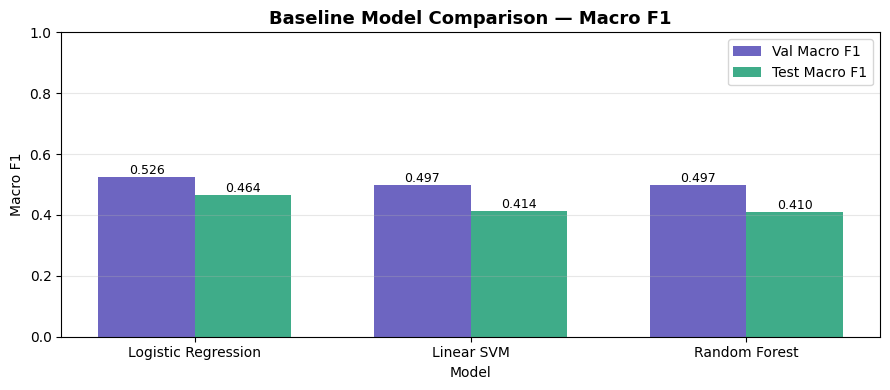

Saved: 03_baseline_comparison.png


In [11]:
# ── Bar chart comparison ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(results))
width = 0.35

ax.bar(x - width/2, results['Val Macro F1'],  width, label='Val Macro F1',  color='#534AB7', alpha=0.85)
ax.bar(x + width/2, results['Test Macro F1'], width, label='Test Macro F1', color='#1D9E75', alpha=0.85)

ax.set_xlabel('Model')
ax.set_ylabel('Macro F1')
ax.set_title('Baseline Model Comparison — Macro F1', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results['Model'])
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

for i, (val, test) in enumerate(zip(results['Val Macro F1'], results['Test Macro F1'])):
    ax.text(i - width/2, val + 0.01, f'{val:.3f}', ha='center', fontsize=9)
    ax.text(i + width/2, test + 0.01, f'{test:.3f}', ha='center', fontsize=9)

plt.tight_layout()
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/03_baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_baseline_comparison.png')

In [12]:
# ── Detailed classification report for best model ──────────────
best_model_name = results.iloc[0]['Model']
best_test_pred = {
    'Linear SVM': svm_test_pred,
    'Logistic Regression': lr_test_pred,
    'Random Forest': rf_test_pred
}[best_model_name]

print(f'Detailed report — {best_model_name}:')
print(classification_report(y_test, best_test_pred, target_names=['negative', 'neutral', 'positive']))

Detailed report — Logistic Regression:
              precision    recall  f1-score   support

    negative       0.84      0.48      0.61      1337
     neutral       0.16      0.59      0.26       224
    positive       0.54      0.52      0.53       438

    accuracy                           0.50      1999
   macro avg       0.51      0.53      0.46      1999
weighted avg       0.70      0.50      0.55      1999



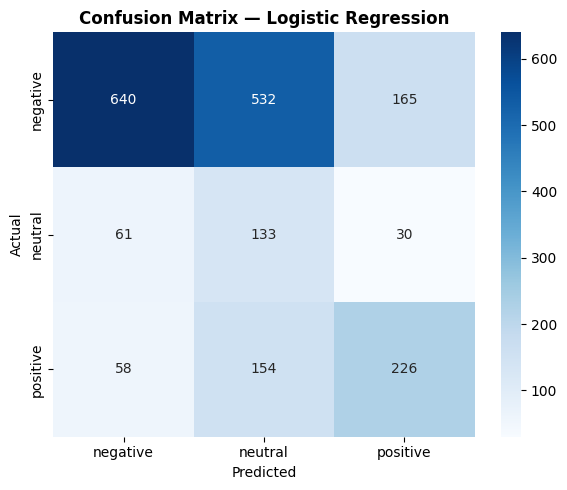

Saved: 03_baseline_confusion_matrix.png


In [13]:
# ── Confusion matrix for best model ───────────────────────────
cm = confusion_matrix(y_test, best_test_pred, labels=['negative', 'neutral', 'positive'])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/03_baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_baseline_confusion_matrix.png')

## 5. Save Best Baseline Model

In [14]:
# ── Save best model and TF-IDF vectorizer ─────────────────────
os.makedirs('../models', exist_ok=True)

best_model = {
    'Linear SVM': svm,
    'Logistic Regression': lr,
    'Random Forest': rf
}[best_model_name]

joblib.dump(best_model, '../models/baseline_model.joblib')
joblib.dump(tfidf, '../models/tfidf_vectorizer.joblib')

print(f'✅ Saved best baseline: {best_model_name}')
print(f'   ../models/baseline_model.joblib')
print(f'   ../models/tfidf_vectorizer.joblib')
print(f'\nBaseline Macro F1 to beat: {results.iloc[0]["Test Macro F1"]:.4f}')
print('Proceed to Day 6 — HuggingFace tokenization.')

✅ Saved best baseline: Logistic Regression
   ../models/baseline_model.joblib
   ../models/tfidf_vectorizer.joblib

Baseline Macro F1 to beat: 0.4640
Proceed to Day 6 — HuggingFace tokenization.


## 6. Summary

| Model | Val Macro F1 | Test Macro F1 | Test Accuracy |
|---|---|---|---|
| Linear SVM | 0.4972 | 0.4139 | 0.4277 |
| Logistic Regression | **0.5256** | **0.4640** | **0.4997** |
| Random Forest | 0.4975 | 0.4099 | 0.4202 |

**Best baseline model**: Logistic Regression  
**Baseline Macro F1 to beat**: 0.4640

**Why Logistic Regression won here (not SVM)**:  
Unusually, Logistic Regression outperformed SVM. This is likely due to the severe train/test distribution shift — the test set is 66.9% negative vs 51.9% neutral in train. Logistic Regression's probabilistic output handles this shift better than SVM's hard margin.

**Why the numbers look low**:  
The neutral class only has 224 samples in the test set (vs 1,337 negative), dragging macro F1 down to 0.26 for neutral alone. This is a dataset distribution problem, not a model failure. It directly motivates the transformer approach.

**Limitations of TF-IDF + classical ML**:
- Treats each word independently — no understanding of word order or context
- Cannot handle out-of-vocabulary words seen at test time
- No semantic understanding — 'ጥሩ' and 'አስደናቂ' (both positive words) are treated as completely unrelated
- These limitations motivate the transformer approach on Day 7

**Next steps (Day 5 — Error Analysis)**:
- Load best baseline model
- Find which tweets it got wrong
- Understand which sentiment class is hardest
- Use findings to motivate the transformer